In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
def f(x):
    return 3*x**2 - 4*x + 5

In [4]:
f(3.0)

20.0

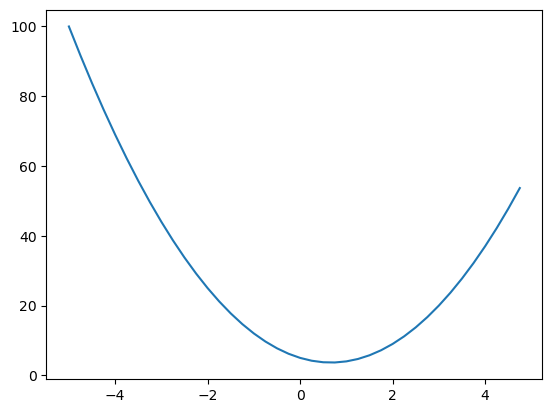

In [5]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs,ys)

In [6]:
h = 0.00000001
x=3.0
def der(x,h):
    return (f(x+h) - f(x))/h
c = 2/3

der(c,h)


0.0

In [7]:
# lets get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b +c
print(d)

4.0


In [8]:
h = 0.0001
a = 2.0
b = -3.0
c = 10.0
d1 = a*b +c
a+=h
d2 = a*b +c

print('d1',d1)
print('d2',d2)
print("slope",(d2-d1)/h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [9]:
class Value:
    def __init__(self,data,_children=(),_op='',label=''):
        self.data= data
        self._prev = set(_children)
        self._op = _op
        self.label=label
        self.grad=0.0
        self._backward = lambda : None

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data+other.data,(self,other),'+')
        other = other if isinstance(other,Value) else Value(other)
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0*out.grad
        out._backward = _backward
        return out
    def __radd__(self,other):
        return self+other
    
    def __mul__(self,other):
        other = other if isinstance(other,Value) else Value(other)

        out = Value(self.data*other.data,(self,other),'*')
        other = other if isinstance(other,Value) else Value(other)
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self,other):
        return self*other
    # we need to accumulate the gradients because duplicate objects will override the grad and will give out incorrect grad on backward pass
    def tanh(self):
        n = self.data
        t = (math.exp(2*n) -1)/(math.exp(2*n)+1)
        out = Value(t,(self,),'tanh')
        def _backward():
            self.grad = (1 - t**2) * out.grad
        out._backward = _backward
        return out
    
    def __neg__(self):
        return self*-1
    
    def __sub__(self,other):
        return self+(-other)
    
    def __pow__(self,other):
        assert isinstance(other,(int,float))
        out = Value(self.data**other,(self,),f'**{other}')
        def _backward():
            self.grad = (other)*(self.data**(other-1))*out.grad
        out._backward = _backward
        return out
        
    def exp(self):
        out  = Value(math.exp(self.data),(self,),'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
    
    def __truediv__(self, other):
        return self*(other**-1)
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad=1.0
        for node in reversed(topo):
            node._backward()


a = Value(2.0,label='a')
b = Value(-3.0,label='b')
c = Value(10.0,label='c')
e = a*b;e.label='e'
d = e+c;d.label='d'
f = Value(-2.0,label='f')
L = f*d;L.label='L'

In [10]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [11]:
d._op

'+'

In [12]:
from graphviz import Digraph
def trace(root):
    nodes,edges=set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges

def draw_dot(root):
    dot = Digraph(format="svg",graph_attr={'rankdir':'LR'})

    nodes,edges=trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid,label="{%s | data %.4f | grad %.4f}"%(n.label,n.data,n.grad),shape='record')
        if n._op:
            dot.node(name=uid+n._op,label=n._op)
            dot.edge(uid+n._op,uid)

    for n1,n2 in edges:
        dot.edge(str(id(n1)),str(id(n2))+n2._op)
    
    return dot

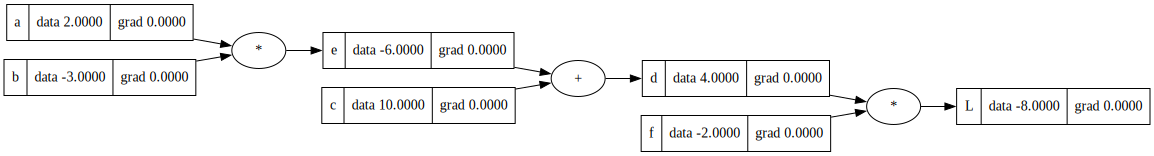

In [13]:
draw_dot(L)

L = d*f
dl/dd = f

(f(x+h) - f(x))/h

-> ((d+h)*f - d*f)/h
-> f


dL/dc=?
-> dL/dd * dd/dc
dd/dc = 1.0
dd/de = 1.0


dL/da = dL/dd * dd/de * de/da
e = a*b
de/da = b

In [14]:
L.grad=1
f.grad = d.data
d.grad = f.data

c.grad = d.grad
e.grad = d.grad

a.grad = b.data*e.grad
b.grad = a.data*e.grad



In [15]:
a.data+=0.01*a.grad
b.data+=0.01*b.grad
c.data+=0.01*c.grad
f.data+=0.01*f.grad


e = a*b
d = e+c
L = f*d
L

Value(data=-7.286496)

In [16]:
def lol():
    h=0.01
    a = Value(2.0,label='a')
    b = Value(3.0,label='b')
    c = Value(5.0,label='c')
    e = a*b;e.label='e'
    d = e+c;d.label='d'
    f = Value(-2.0,label='f')
    L = f*d;L.label='L'
    L1 = L.data
    
    a = Value(2.0,label='a')
    b = Value(3.0,label='b')
    c = Value(5.0,label='c')
    e = a*b;e.label='e'
    d = e+c;d.label='d'
    d.data+=h
    f = Value(-2.0,label='f')
    L = f*d;L.label='L'
    L2 = L.data

    print((L2-L1)/h)

lol()
# all this is just gradient of L wrt d -> f

-1.9999999999999574


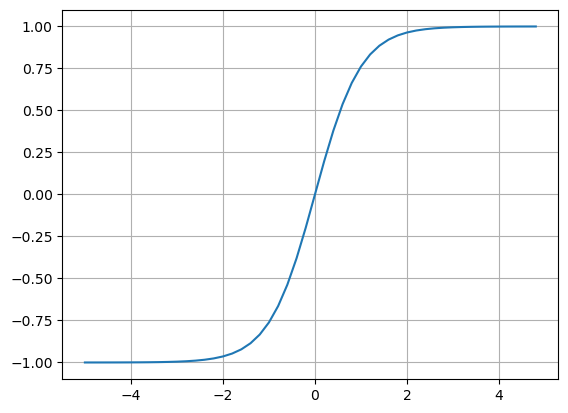

In [17]:
plt.plot(np.arange(-5,5,0.2),np.tanh(np.arange(-5,5,0.2)))
plt.grid()

In [18]:
x1 = Value(2.0,label='x1')
x2 = Value(0.0,label='x2')
#weights w1,w2
w1 = Value(-3.0,label='w1')
w2 = Value(1.0,label='w2')
#bias of the neuron
b = Value(6.8813735870195432,label='b')

x1w1=x1*w1;x1w1.label='x1w1'
x2w2=x2*w2;x2w2.label='x2w2'
x1w1x2w2 = x1w1+x2w2;x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2+b;n.label='n'
o = n.tanh();o.label='o'




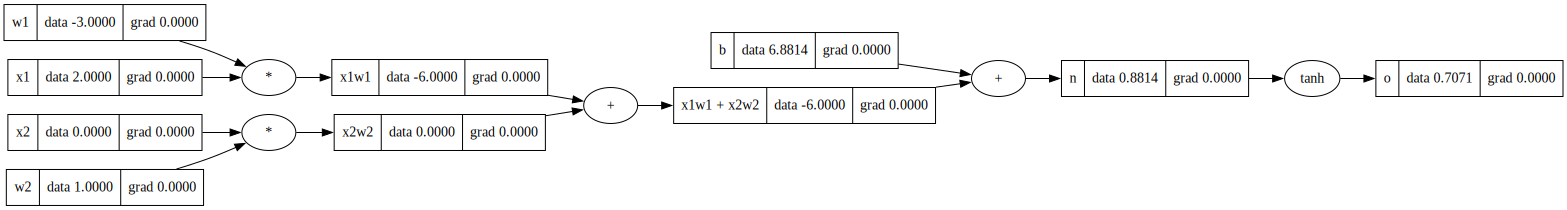

In [19]:
draw_dot(o)

In [20]:
o.backward()


# topological sort

In [21]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)

build_topo(o)
topo

[Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [22]:
o._grad = 1.0
o._backward()
n._backward()
x1w1x2w2._backward()
x2w2._backward()
x1w1._backward()


In [23]:
o.grad=1.0
n.grad = 1 - o.data**2

x1w1x2w2.grad = n.grad
b.grad = n.grad

x1w1.grad = x1w1x2w2.grad
x2w2.grad = x1w1x2w2.grad

w1.grad = x1.data*x1w1.grad
w2.grad = x2.data*x2w2.grad


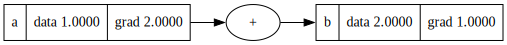

In [24]:
a = Value(1.0,label='a')
b = a + a;b.label='b'
b.backward()
draw_dot(b)

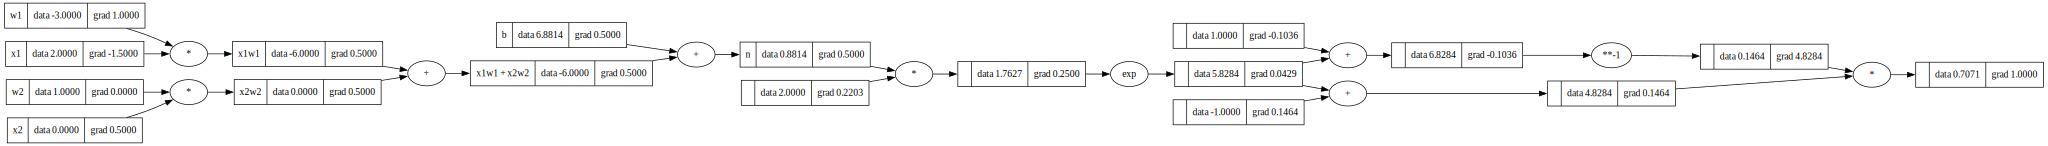

In [25]:
x1 = Value(2.0,label='x1')
x2 = Value(0.0,label='x2')
#weights w1,w2
w1 = Value(-3.0,label='w1')
w2 = Value(1.0,label='w2')
#bias of the neuron
b = Value(6.8813735870195432,label='b')

x1w1=x1*w1;x1w1.label='x1w1'
x2w2=x2*w2;x2w2.label='x2w2'
x1w1x2w2 = x1w1+x2w2;x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2+b;n.label='n'
e = (2*n).exp()
o = (e-1)/(e+1)
o.backward()
draw_dot(o)

In [26]:
import torch

x1 = torch.tensor([2.0],dtype = float,requires_grad=True)
x2 = torch.tensor([0.0],dtype = float,requires_grad=True)
w1 = torch.tensor([-3.0],dtype = float,requires_grad=True)
w2 = torch.tensor([1.0],dtype = float,requires_grad=True)
b = torch.tensor([6.8813735870195432],dtype = float,requires_grad=True)
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print(x2.grad.item())

0.7071067811865476
0.4999999999999999


In [27]:
class Neuron:
    def __init__(self,nin):
        self.w = [Value(np.random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(np.random.uniform(-1,1))

    
    def __call__(self,x):
        act = sum((wi*xi for wi , xi in zip(self.w,x)), self.b)
        out  = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]
    
class Layer:
    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    
    def __call__(self,x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out)==1 else out
    
    def parameters(self):
        params = []
        for neuron in self.neurons:
            ps = neuron.parameters()
            params.extend(ps)
        return params
    
class MLP:
    def __init__(self,nin,nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
        

In [28]:
x = [2.0,3.0]
# n = Neuron(2)
# n = Layer(2,3)
n = MLP(3,[4,4,1])
n(x)

Value(data=-0.8740395471271208)

In [29]:
n.parameters()

[Value(data=0.8439292288014673),
 Value(data=-0.6767603463863732),
 Value(data=-0.1706698734688743),
 Value(data=-0.8638828694258958),
 Value(data=0.16157455955388578),
 Value(data=0.028199615748081497),
 Value(data=-0.8324642032468841),
 Value(data=0.21995984707434424),
 Value(data=0.5195620500949039),
 Value(data=0.7106424363862831),
 Value(data=0.676485514468014),
 Value(data=0.9583879282136927),
 Value(data=-0.28714843374866383),
 Value(data=0.7238876747541583),
 Value(data=-0.2860919995041533),
 Value(data=-0.1670457644279144),
 Value(data=-0.6849494899706798),
 Value(data=-0.251183106111426),
 Value(data=0.6474341991986272),
 Value(data=-0.5853130615253637),
 Value(data=0.8233546180556002),
 Value(data=-0.3213250145372262),
 Value(data=0.01450890497528401),
 Value(data=-0.03286457850517732),
 Value(data=0.48995309014007904),
 Value(data=-0.1887371771992974),
 Value(data=-0.6060795693875121),
 Value(data=-0.25632724915449634),
 Value(data=-0.5940247253712974),
 Value(data=0.587524

In [30]:
xs = [
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0]
    ]
 
ys = [1.0,-1.0,-1.0,1.0]

In [31]:
for k in range(20):  
    #forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout-ygt)**2 for ygt,yout in zip(ys,ypred))

    #backward pass
    for p in n.parameters():
        p.grad = 0.0
        
    loss.backward()

    #update
    for p in n.parameters():
        p.data += -0.05*p.grad

    print(k,loss.data)



0 6.939109199072517
1 5.957903254115315
2 3.0724509765545034
3 1.4724109477855587
4 0.7163518101389779
5 0.45285862520360814
6 0.3203780102592983
7 0.24209904731483772
8 0.19189989802391333
9 0.1575801397327057
10 0.13290188729884933
11 0.114434996331885
12 0.10016829947106236
13 0.08885694198623903
14 0.07969459051622776
15 0.0721386052716793
16 0.0658117673664495
17 0.06044446772973629
18 0.055839330447746235
19 0.051848808064073215


In [32]:
n.layers[0].neurons[0].w[0].grad

-0.02876594578897726

In [33]:
n.layers[0].neurons[0].w[0].data

1.1246385229879023

In [34]:
n.parameters()

[Value(data=1.1246385229879023),
 Value(data=-0.327820292232581),
 Value(data=-0.407600495622904),
 Value(data=-0.6709241646941696),
 Value(data=0.09111918002987628),
 Value(data=0.05500050593641535),
 Value(data=-0.9755850106575814),
 Value(data=0.159827778216942),
 Value(data=0.5082821853193698),
 Value(data=0.6946222366449014),
 Value(data=0.6883287112724397),
 Value(data=0.9444771894520934),
 Value(data=-0.19098899543631492),
 Value(data=0.8146248219872618),
 Value(data=-0.546199714068599),
 Value(data=-0.11081618405650534),
 Value(data=-0.6416475106584744),
 Value(data=-0.6026942394610243),
 Value(data=0.372693164618035),
 Value(data=-0.9241542186636034),
 Value(data=0.5265242911837066),
 Value(data=-0.26577002259854665),
 Value(data=0.3570222903363129),
 Value(data=0.008222214454990065),
 Value(data=0.724286197693962),
 Value(data=-0.13264295233431128),
 Value(data=-0.6466394891902667),
 Value(data=-0.45724181457422347),
 Value(data=-0.6071510750991859),
 Value(data=0.48630355033

In [ ]:
ypred

TypeError: unhashable type: 'list'

o = tanh(n)
do/dn = 1 - (tanh(n))^2 => 1 - o**2